In [1]:
import pickle
from main import Result
from src import SBsim
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
from src import SBsim_OG
import os
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
#Input Variables
drought_type = [87, 0.83, 2]


In [3]:
def plot_trees(ptrees):
    fig, axes = plt.subplots(1, len(ptrees), figsize=(30, 6))
    if len(ptrees) == 1:
        axes = [axes]
    
    for ax, ptree in zip(axes, ptrees):
        G = nx.DiGraph()
        pos = {}
        labels = {}
        edge_labels = {}
        
        def add_nodes_edges(node, parent=None, pos_x=0, pos_y=0, depth=1, is_left=None):
            node_id = id(node)
            pos[node_id] = (pos_x, -pos_y)
            labels[node_id] = str(node)
            G.add_node(node_id)
            
            if parent is not None:
                G.add_edge(id(parent), node_id)
                edge_labels[(id(parent), node_id)] = "True" if is_left else "False"
            
            if hasattr(node, 'l') and node.l:
                add_nodes_edges(node.l, node, pos_x - 1 / depth, pos_y + 1, depth + 1, is_left=True)
            if hasattr(node, 'r') and node.r:
                add_nodes_edges(node.r, node, pos_x + 1 / depth, pos_y + 1, depth + 1, is_left=False)
        
        add_nodes_edges(ptree.root, is_left=None)
        axes[0].set_title('Deploy Centralized')
        axes[1].set_title('Deploy Decentralized')
        axes[2].set_title('Curtailment')
        axes[3].set_title('Decommision Centralized')
        axes[4].set_title('Decommision Decentralized')
        axes[5].set_title('Decommision Curtailment')
        
        nx.draw(G, pos, with_labels=True, labels=labels, node_size=2000, node_color='lightblue', font_size=6, edge_color='gray', ax=ax)
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10, ax=ax)
    
    plt.show()

In [4]:
# set optimization parameters
class OptimizationParameters(object):
    def __init__(self):
        self.cores    = 36 # this value is used only in the full scale optimization
        self.nseeds   = 1
        self.nobjs    = 1
        self.drought_type = drought_type # set drought type here [Persistence (months), Intensity (unitless), Frequency (droughts/100 years)]

#initialize action table
action = [] #Action Name
capacity = [] #Capacity (Acre-Feet/Month)
om = [] #Operation and Maintenance Costs (Million Dollars/ Acre-Feet/ Year)
cx = [] #CAPEX (Million Dollars)
lifetime = [] #Years
t_depl = [] #Time to Deployment (Month)
action_type = [] # types 1: Deploy Centralized Infrastructure, 2: Commision Decentralized Infrastructure, 3: Decommission Centralized Infrastructure, 4: Decommission Centralized Infrastructure, 5: Conservation

#Read the action table
df_actions_table = pd.read_csv("data/actions_table.csv")
action = df_actions_table['action'].values
capacity = df_actions_table['capacity (af/month)'].values
om = df_actions_table['OPEX ($10^6/af/year)'].values
cx = df_actions_table['CAPEX($10^6)'].values
t_depl = df_actions_table['time to deployment (month)'].values
lifetime = df_actions_table['lifetime (year)'].values
action_type = [int(val) for val in df_actions_table['action_type'].values]

action_name = [[], [], [], [], []]
i = 0
for act in action:
        action_name[action_type[i]].extend( [act] )
        i += 1

opt_par = OptimizationParameters()
model_sim = SBsim(opt_par, action_name, capacity, om, cx, t_depl, lifetime) 
model_sim_OG = SBsim_OG(opt_par, action_name, capacity, om, cx, t_depl, lifetime)

In [5]:
#Inputs for cost of curtailment experiment
end_cost = 500
step = 10
length = int(500/10)

In [ ]:
list_fail = []
objs = []
Costs = []
for i in range(length):
    if i in list_fail:
        continue
    open_file = open(f"/home/gkittles/SB_DRIPP_Results/5_29_25_Parameter_Sweep/results/test_results87_0.83_1{i*step}.dat", "rb")
    objs.append(pickle.load(open_file))
    Costs.append(i*step)

FileNotFoundError: [Errno 2] No such file or directory: '/home/gkittles/SB_DRIPP_Results/5_7_25_Curtailment_Cost/results/test_results87_0.83_10.dat'

In [7]:
average_cost = []
logging = []
average_jcost = []
all_costs = []
all_jcosts = []
j = 0
for obj in objs:
    cost = []
    jcost = []
    model_sim = SBsim(opt_par, action_name, capacity, om, cx, t_depl, lifetime, curtailment_unitcost=j*10)
    for i in range(5):
        log = model_sim.simulate(obj.best_solution, i)
        cost.append(log.Cost)
        jcost.append(log.J)
    all_costs.append(cost)
    all_jcosts.append(jcost)
    average_cost.append(np.mean(cost))
    logging.append(log)
    average_jcost.append(np.mean(jcost))
    j = j + 1

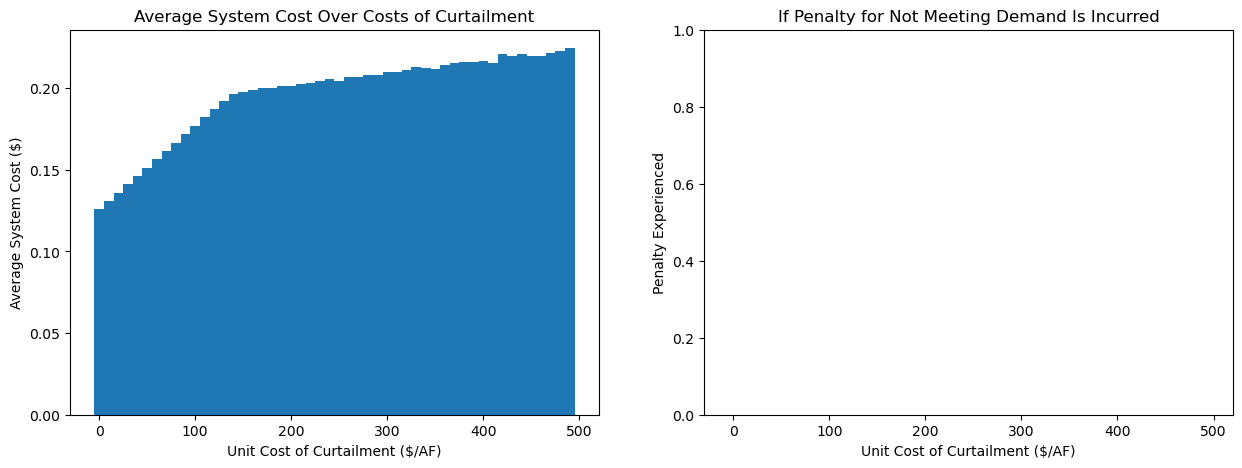

In [8]:
plt.figure(figsize = (15,5))

plt.subplot(1,2,1)
plt.bar(Costs, average_cost, width = step);
plt.xlabel('Unit Cost of Curtailment ($/AF)');
plt.ylabel('Average System Cost ($)');
plt.title("Average System Cost Over Costs of Curtailment");

plt.subplot(1,2,2)
penalty = []
for i in range(len(average_cost)):
    val = average_jcost[i] - average_cost[i]
    if val == 0:
        penalty.append(0)
    else:
        penalty.append(1)
plt.bar(Costs, penalty, width = step);
plt.ylabel('Penalty Experienced');
plt.xlabel("Unit Cost of Curtailment ($/AF)");
plt.title("If Penalty for Not Meeting Demand Is Incurred");
plt.ylim(0,1);

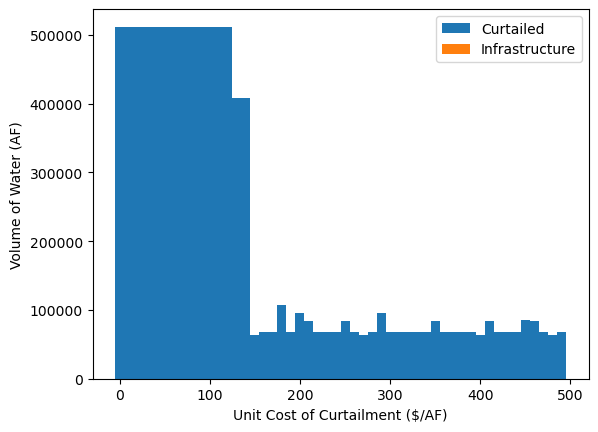

In [9]:
total_curtailment = []
total_infrastructure = []
for log in logging:
    curtailment_sum = sum(log.reduction_magn)
    infrastructure_sum = sum(log.capacity)
    total_curtailment.append(curtailment_sum)
    total_infrastructure.append(infrastructure_sum)

plt.bar(Costs, total_curtailment, label = "Curtailed", width = step)
plt.bar(Costs, total_infrastructure, label = "Infrastructure", width = step)
plt.xlabel("Unit Cost of Curtailment ($/AF)")
plt.ylabel("Volume of Water (AF)")
plt.legend();

In [10]:
#which cost of curtailment simulated
ind = int(400/step)

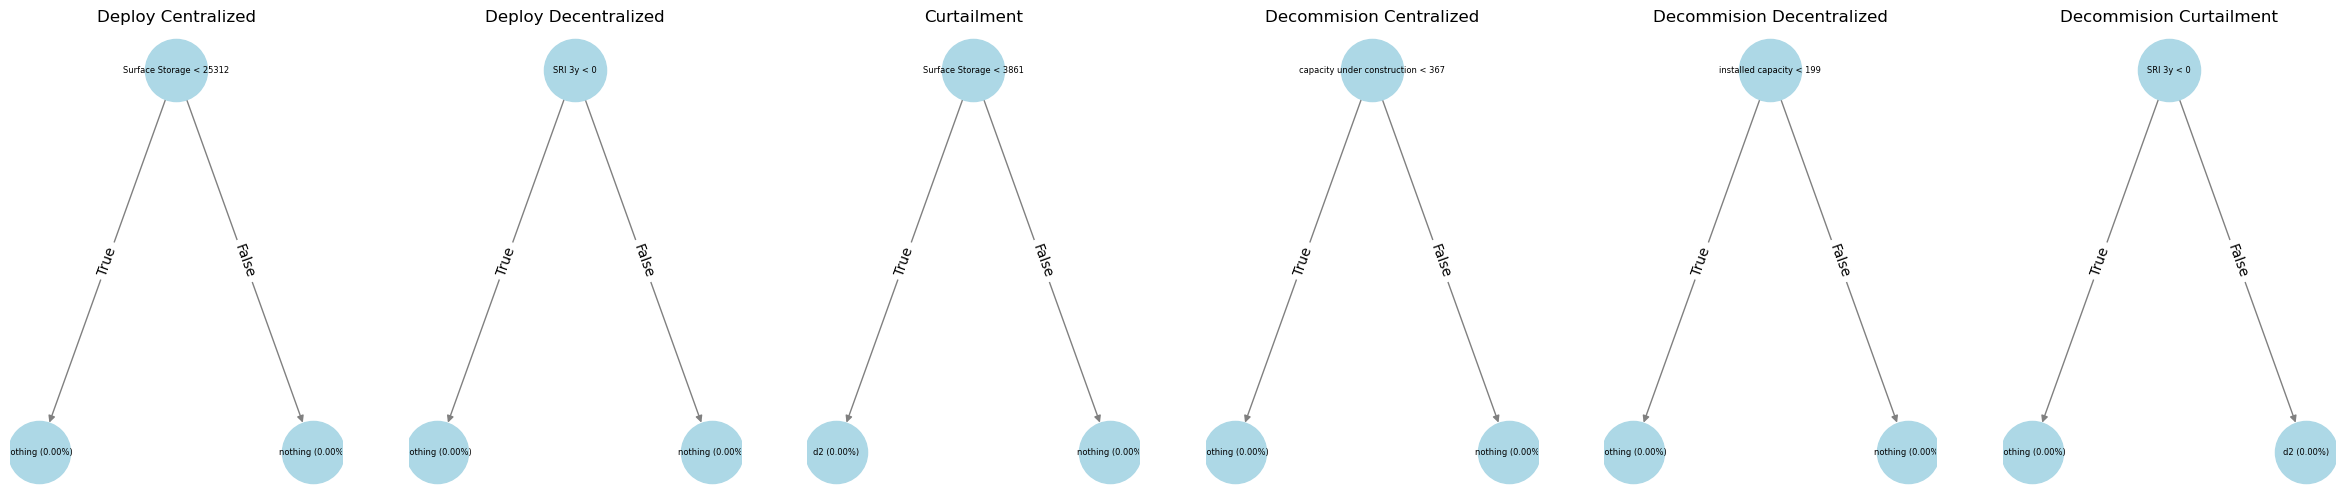

In [11]:
plot_trees(objs[ind].best_solution);

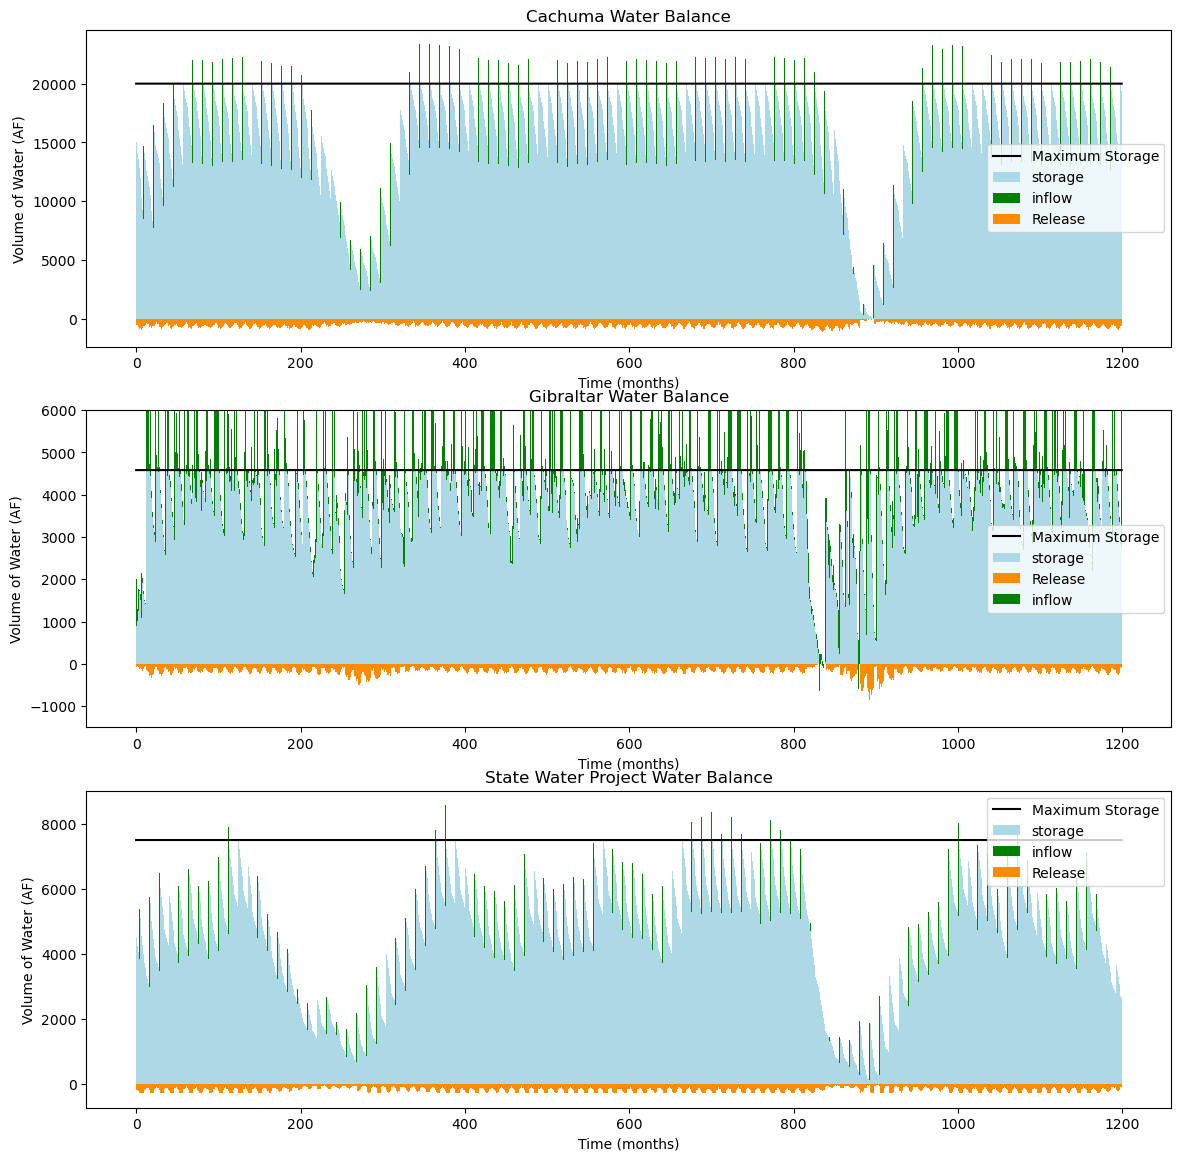

In [12]:
plt.figure(figsize = (14,14))

plt.subplot(3,1,1)
#plt.plot(logging[ind].sc,label = "Water level",color='purple');
plt.plot(20000.0*np.ones(1200), label = "Maximum Storage", color = 'black')
plt.bar(range(1200),logging[ind].sc, label = "storage", width = 1, color = 'lightblue')
plt.bar(range(1200), logging[ind].nc, bottom = logging[ind].sc, label = "inflow", width = 1, color = 'green')
#plt.bar(range(1200), logging[ind].rc, bottom = [i + s for i,s in zip(logging[ind].nc, logging[ind].sc)], label = "release", width = 1, color = 'darkorange')
plt.bar(range(1200), [-1*r for r in logging[ind].rc], width = 1, color = 'darkorange', label = 'Release')
plt.title("Cachuma Water Balance")
plt.xlabel('Time (months)');
plt.ylabel('Volume of Water (AF)');
plt.legend();

plt.subplot(3,1,2)
#plt.plot(logging[ind].sgi,label = "Water level",color='purple');
plt.plot(4583*np.ones(1200), label = "Maximum Storage", color = 'black')
plt.bar(range(1200),logging[ind].sgi[:-1], label = "storage", width = 1, color = 'lightblue')
#plt.bar(range(1200), logging[ind].rgi, bottom = [i + s for i,s in zip(logging[ind].ngi, logging[ind].sgi[:-1])], label = "release", width = 1, color = 'darkorange')
plt.bar(range(1200), [-1*r for r in logging[ind].rgi], width = 1, color = 'darkorange', label = 'Release')
plt.bar(range(1200), logging[ind].ngi, bottom = logging[ind].sgi[:-1], label = "inflow", width = 1, color = 'green')
plt.title("Gibraltar Water Balance")
plt.ylim(-1500,6000)
plt.xlabel('Time (months)');
plt.ylabel('Volume of Water (AF)');
plt.legend();

plt.subplot(3,1,3)
#plt.plot(logging[ind].sswp,label = "Water level",color='purple');
plt.plot(7500*np.ones(1200), label = "Maximum Storage", color = 'black')
plt.bar(range(1200),logging[ind].sswp[:-1], label = "storage", width = 1, color = 'lightblue')
plt.bar(range(1200), logging[ind].nswp, bottom = logging[ind].sswp[:-1], label = "inflow", width = 1, color = 'green')
#plt.bar(range(1200), logging[ind].rswp, bottom = [i + s for i,s in zip(logging[ind].nswp, logging[ind].sswp[:-1])], label = "release", width = 1, color = 'darkorange')
plt.bar(range(1200), [-1*r for r in logging[ind].rswp], width = 1, color = 'darkorange', label = 'Release')
plt.title("State Water Project Water Balance");
plt.xlabel('Time (months)');
plt.ylabel('Volume of Water (AF)');
plt.legend();

#plt.savefig('water_balance.png', dpi = 1000)

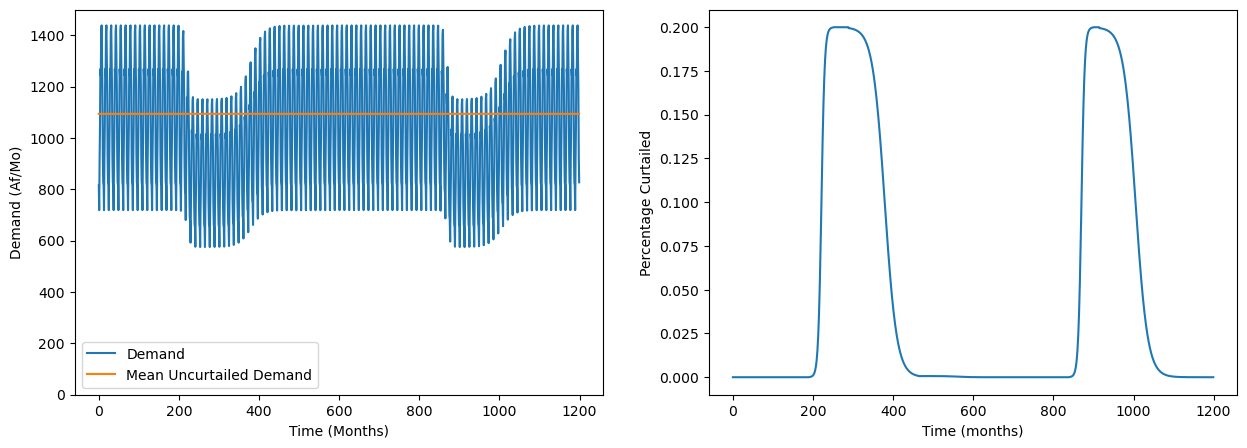

In [13]:
plt.figure(figsize = (15,5))

plt.subplot(1,2,1)
demand = [814.98, 719.26, 913.5, 1048, 1268.8, 1243, 1415.9, 1438.9, 1317.5, 1193.8, 931, 827.54]
plt.plot(logging[ind].curtailed_demand, label = f"Demand");
plt.plot((sum(demand)/len(demand))*np.ones(len(logging[ind].curtailed_demand)), label = "Mean Uncurtailed Demand")
plt.xlabel('Time (Months)');
plt.ylabel('Demand (Af/Mo)');
plt.ylim(0,1500);
plt.legend();

plt.subplot(1,2,2)
plt.plot(logging[ind].reduction_perc);
plt.xlabel("Time (months)");
plt.ylabel("Percentage Curtailed");

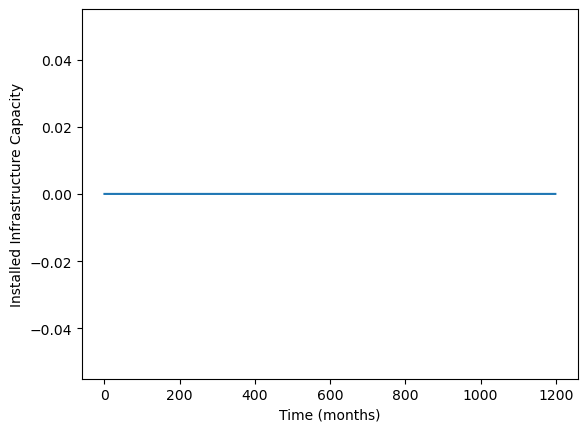

In [14]:
plt.plot(logging[ind].capacity);
plt.xlabel('Time (months)');
plt.ylabel("Installed Infrastructure Capacity");

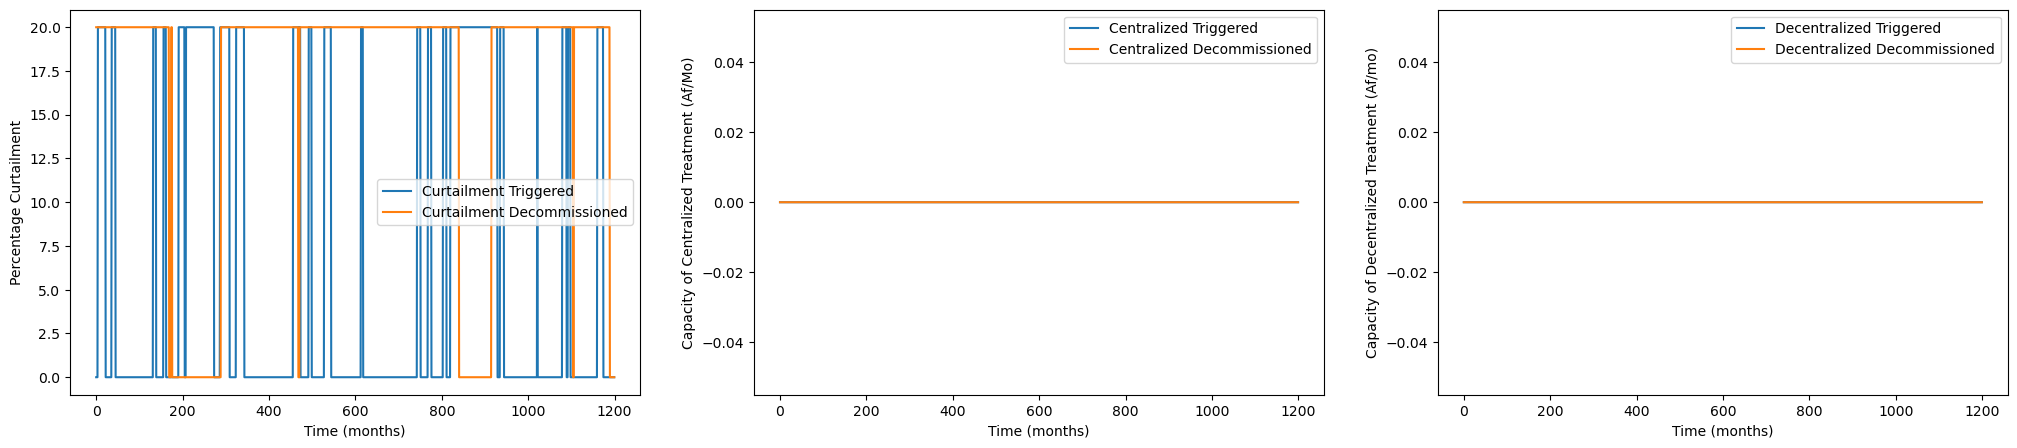

In [15]:
cen = []
dec = []
con = []
rmc = []
rmd = []
rco = []

for policy in logging[ind].policy_triggered:
    cen.append(capacity[np.where(action == policy[0])[0][0]])
    dec.append(capacity[np.where(action == policy[1])[0][0]])
    con.append(capacity[np.where(action == policy[2])[0][0]])
    rmc.append(capacity[np.where(action == policy[3])[0][0]])
    rmd.append(capacity[np.where(action == policy[4])[0][0]])
    rco.append(capacity[np.where(action == policy[5])[0][0]])

plt.figure(figsize = (25,5))

plt.subplot(1,3,1)
plt.plot(con, label = "Curtailment Triggered");
plt.plot(rco, label = "Curtailment Decommissioned");
plt.legend();
plt.xlabel("Time (months)");
plt.ylabel("Percentage Curtailment");

plt.subplot(1,3,2)
plt.plot(cen, label = "Centralized Triggered")
plt.plot(rmc, label = "Centralized Decommissioned")
plt.legend();
plt.xlabel("Time (months)");
plt.ylabel("Capacity of Centralized Treatment (Af/Mo)");

plt.subplot(1,3,3)
plt.plot(dec, label = "Decentralized Triggered");
plt.plot(rmd, label = "Decentralized Decommissioned");
plt.legend();
plt.ylabel("Capacity of Decentralized Treatment (Af/mo)");
plt.xlabel("Time (months)");